# CricIntel AI – Exploratory Data Analysis (EDA)

## Objective

This notebook explores the cleaned IPL Ticket Sales datasets using statistical summaries and visualizations.

### Sections

- Dataset Overview
- Univariate Analysis
- Bivariate Analysis
- Business Insights

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [32]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
 pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [34]:
import sys

print(sys.executable)

C:\Users\venka\anaconda3\envs\myenv\python.exe


In [35]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [36]:
matches = pd.read_csv("../../data/raw/Matches.csv")
customers = pd.read_csv("../../data/raw/Customers.csv")
ticket_sales = pd.read_csv("../../data/raw/Ticket_Sales.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [48]:
from pathlib import Path

# =====================================================
# Project Paths
# =====================================================

PROJECT_ROOT = Path.cwd().parent.parent

RAW_DATA_FOLDER = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_FOLDER = PROJECT_ROOT / "data" / "processed"

REPORTS_FOLDER = PROJECT_ROOT / "reports"
CHARTS_FOLDER = REPORTS_FOLDER / "charts"

# Create folders if they don't exist
PROCESSED_DATA_FOLDER.mkdir(parents=True, exist_ok=True)
CHARTS_FOLDER.mkdir(parents=True, exist_ok=True)

print("Project Root      :", PROJECT_ROOT)
print("Raw Data Folder    :", RAW_DATA_FOLDER)

print("Processed Folder   :", PROCESSED_DATA_FOLDER)

print("Reports Folder     :", REPORTS_FOLDER)
print("Charts Folder     :", CHARTS_FOLDER)

Project Root      : C:\Users\venka\OneDrive\Desktop\CricIntel-AI
Raw Data Folder    : C:\Users\venka\OneDrive\Desktop\CricIntel-AI\data\raw
Processed Folder   : C:\Users\venka\OneDrive\Desktop\CricIntel-AI\data\processed
Reports Folder     : C:\Users\venka\OneDrive\Desktop\CricIntel-AI\reports
Charts Folder     : C:\Users\venka\OneDrive\Desktop\CricIntel-AI\reports\charts


In [49]:
from pathlib import Path
import os
import shutil

# -----------------------------
# Project Paths
# -----------------------------
PROJECT_ROOT = Path.cwd().parent.parent
REPORTS_FOLDER = PROJECT_ROOT / "reports"
CHARTS_FOLDER = REPORTS_FOLDER / "charts"

print("Reports Folder :", REPORTS_FOLDER)
print("Charts Path    :", CHARTS_FOLDER)

# -----------------------------
# Fix Charts Folder
# -----------------------------
if CHARTS_FOLDER.exists():

    if CHARTS_FOLDER.is_file():
        print("⚠ 'charts' is a FILE. Removing it...")
        CHARTS_FOLDER.unlink()

    elif not CHARTS_FOLDER.is_dir():
        print("⚠ 'charts' is not a directory. Removing it...")
        shutil.rmtree(CHARTS_FOLDER, ignore_errors=True)

# Create charts folder
CHARTS_FOLDER.mkdir(parents=True, exist_ok=True)

print("\nCharts Folder Created Successfully!")

print("Exists      :", CHARTS_FOLDER.exists())
print("Is Directory:", CHARTS_FOLDER.is_dir())

# -----------------------------
# Test Writing
# -----------------------------
test_file = CHARTS_FOLDER / "test.txt"

with open(test_file, "w") as f:
    f.write("Testing Successful")

print("\nTest File Created Successfully!")
print(test_file)

Reports Folder : C:\Users\venka\OneDrive\Desktop\CricIntel-AI\reports
Charts Path    : C:\Users\venka\OneDrive\Desktop\CricIntel-AI\reports\charts

Charts Folder Created Successfully!
Exists      : True
Is Directory: True

Test File Created Successfully!
C:\Users\venka\OneDrive\Desktop\CricIntel-AI\reports\charts\test.txt


In [57]:
# =====================================================
# Reusable Bar Chart Function
# =====================================================

def create_bar_chart(data, title, xlabel, ylabel, filename, rotation=45):
    plt.figure(figsize=(10, 6))

    data.plot(
        kind="bar",
        edgecolor="black"
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation)

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Chart saved successfully: {filename}")

In [105]:
# =====================================================
# Reusable Pie Chart Function
# =====================================================

def create_pie_chart(data, title, filename):
    plt.figure(figsize=(8, 8))

    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.axis("equal")   # Makes the pie chart circular

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Chart saved successfully: {filename}")

In [50]:
matches["Match_Date"] = pd.to_datetime(matches["Match_Date"])

customers["Registration_Date"] = pd.to_datetime(
    customers["Registration_Date"]
)

ticket_sales["Booking_Date"] = pd.to_datetime(
    ticket_sales["Booking_Date"]
)

print("Date Conversion Completed")

Date Conversion Completed


In [51]:
print("Matches :", matches.shape)

print("Customers :", customers.shape)

print("Ticket Sales :", ticket_sales.shape)

Matches : (74, 12)
Customers : (12000, 15)
Ticket Sales : (150000, 10)


# Univariate Analysis

## Matches Dataset

### Business Question

Which teams are hosting the highest number of IPL matches?

In [52]:
# Home Team Frequency

home_team_counts = matches["Home_Team"].value_counts()

display(home_team_counts)

Home_Team
RR      9
SRH     9
RCB     8
DC      8
GT      8
CSK     8
LSG     7
PBKS    7
MI      6
KKR     4
Name: count, dtype: int64

In [53]:
# Home Team Percentage

home_team_percentage = (
    matches["Home_Team"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(home_team_percentage)

Home_Team
RR      12.16
SRH     12.16
RCB     10.81
DC      10.81
GT      10.81
CSK     10.81
LSG      9.46
PBKS     9.46
MI       8.11
KKR      5.41
Name: proportion, dtype: float64

In [54]:
print("Total Teams :", matches["Home_Team"].nunique())

print("Most Frequent Team :", home_team_counts.idxmax())

print("Matches Hosted :", home_team_counts.max())

Total Teams : 10
Most Frequent Team : RR
Matches Hosted : 9


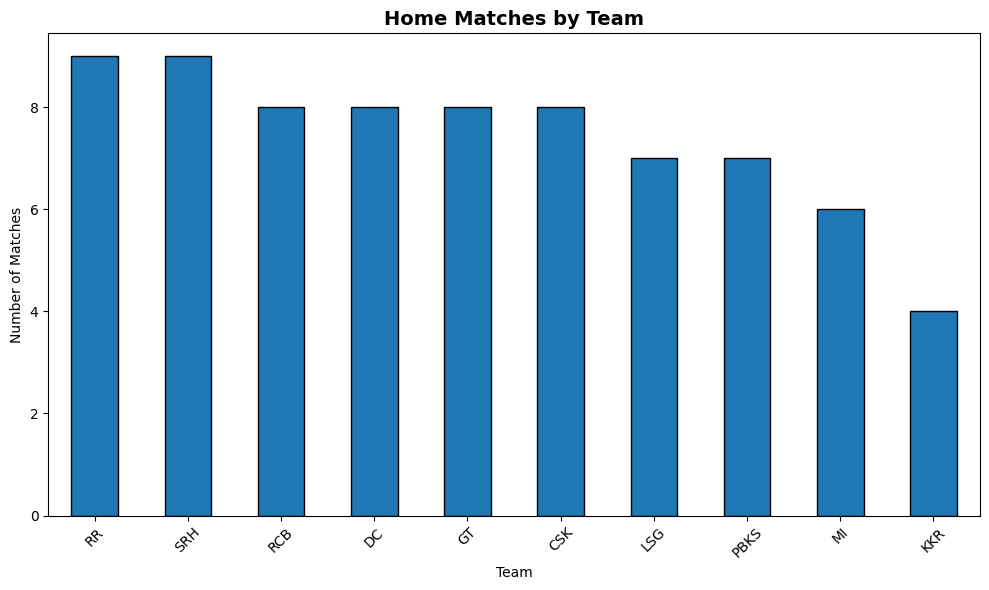

Chart saved successfully: home_team_distribution.png


In [59]:
create_bar_chart(
    data=home_team_counts,
    title="Home Matches by Team",
    xlabel="Team",
    ylabel="Number of Matches",
    filename="home_team_distribution.png"
)

### Business Insight

- Home matches are distributed fairly across all IPL teams.
- Teams hosting more matches have greater opportunities to generate ticket revenue and increase local fan engagement.
- The schedule appears balanced without significant bias toward any franchise.

## Business Question

Which teams play the highest number of away matches?

In [60]:
away_team_counts = matches["Away_Team"].value_counts()

display(away_team_counts)

Away_Team
RCB     9
PBKS    9
MI      8
CSK     8
GT      8
SRH     7
KKR     7
LSG     6
DC      6
RR      6
Name: count, dtype: int64

In [61]:
away_team_percentage = (
    matches["Away_Team"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(away_team_percentage)

Away_Team
RCB     12.16
PBKS    12.16
MI      10.81
CSK     10.81
GT      10.81
SRH      9.46
KKR      9.46
LSG      8.11
DC       8.11
RR       8.11
Name: proportion, dtype: float64

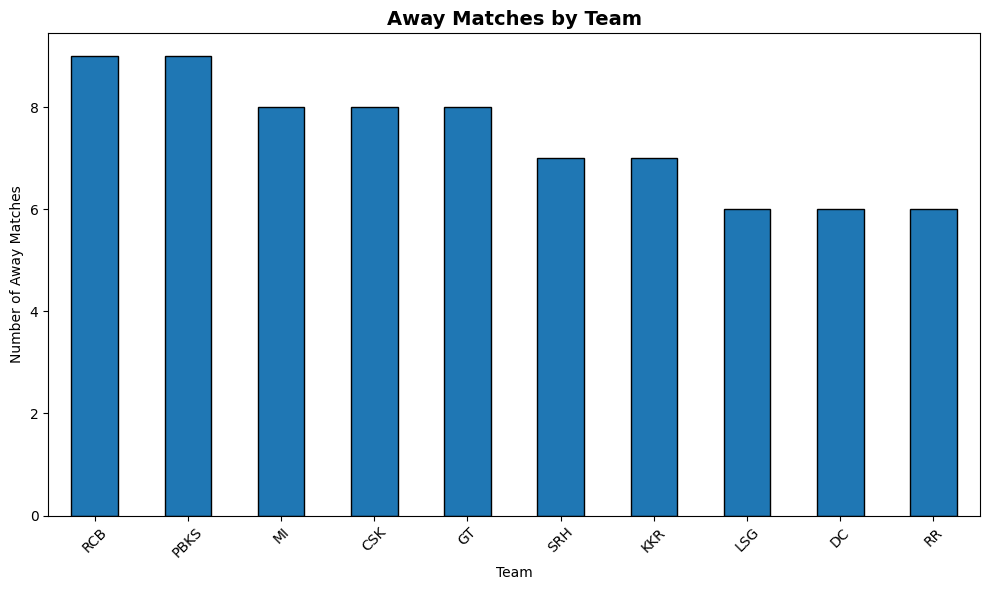

Chart saved successfully: away_team_distribution.png


In [62]:
create_bar_chart(
    data=away_team_counts,
    title="Away Matches by Team",
    xlabel="Team",
    ylabel="Number of Away Matches",
    filename="away_team_distribution.png"
)

### Business Insight

- Away matches are evenly distributed among franchises.
- Balanced away fixtures help ensure fairness throughout the tournament.

## Business Question

Which cities host the highest number of IPL matches?

In [63]:
city_counts = matches["City"].value_counts()

display(city_counts)

City
Jaipur       9
Hyderabad    9
Bengaluru    8
Delhi        8
Ahmedabad    8
Chennai      8
Lucknow      7
Mohali       7
Mumbai       6
Kolkata      4
Name: count, dtype: int64

In [64]:
city_percentage = (
    matches["City"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(city_percentage)

City
Jaipur       12.16
Hyderabad    12.16
Bengaluru    10.81
Delhi        10.81
Ahmedabad    10.81
Chennai      10.81
Lucknow       9.46
Mohali        9.46
Mumbai        8.11
Kolkata       5.41
Name: proportion, dtype: float64

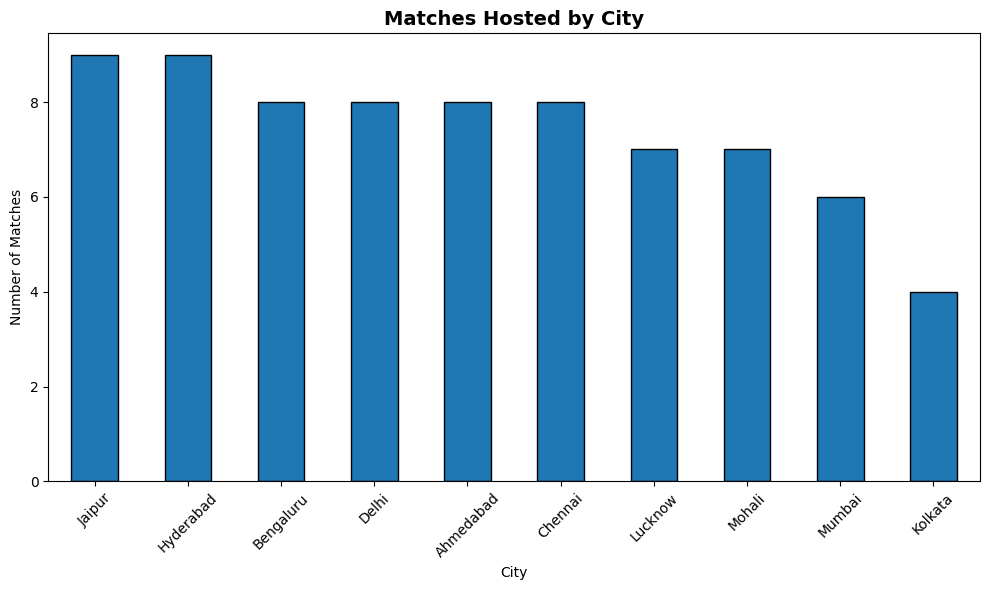

Chart saved successfully: city_distribution.png


In [65]:
create_bar_chart(
    data=city_counts,
    title="Matches Hosted by City",
    xlabel="City",
    ylabel="Number of Matches",
    filename="city_distribution.png"
)

### Business Insight

- Cities hosting more IPL matches contribute significantly to ticket sales and fan engagement.
- These cities are important locations for marketing and operational planning.

## Business Question

Which stadiums host the highest number of IPL matches?

In [69]:
venue_counts = matches["Venue"].value_counts()

display(venue_counts)

Venue
Sawai Mansingh Stadium                9
Rajiv Gandhi International Stadium    9
M. Chinnaswamy Stadium                8
Arun Jaitley Stadium                  8
Narendra Modi Stadium                 8
M. A. Chidambaram Stadium             8
BRSABV Ekana Stadium                  7
Punjab Cricket Association Stadium    7
Wankhede Stadium                      6
Eden Gardens                          4
Name: count, dtype: int64

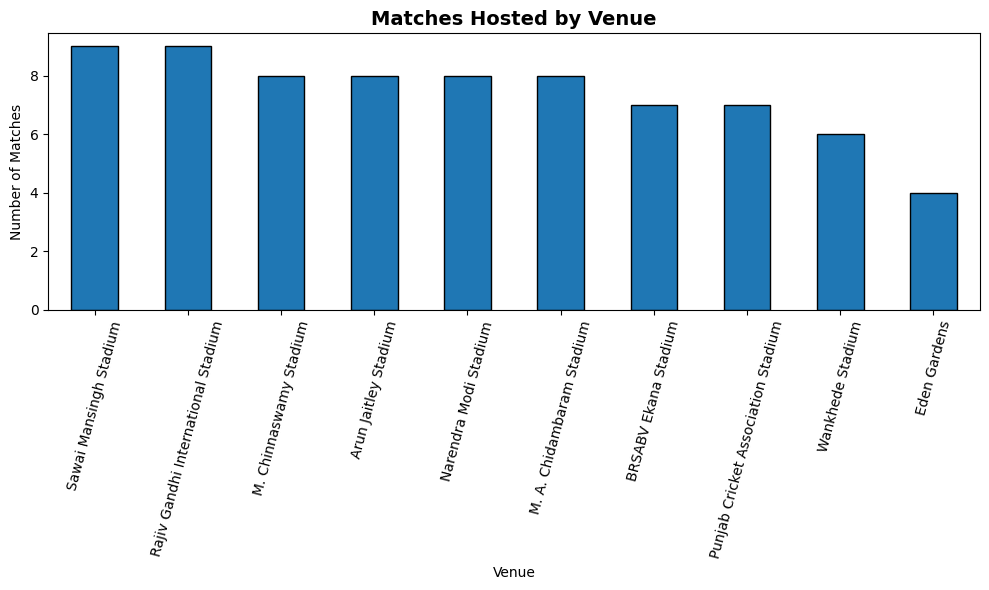

Chart saved successfully: venue_distribution.png


In [70]:
create_bar_chart(
    data=venue_counts,
    title="Matches Hosted by Venue",
    xlabel="Venue",
    ylabel="Number of Matches",
    filename="venue_distribution.png",
    rotation=75
)

### Business Insight

- Venues hosting more IPL matches have greater revenue-generating opportunities through ticket sales and fan engagement.
- High-frequency venues require stronger operational planning and crowd management.
- Venue utilization analysis helps optimize future tournament scheduling.

# Customers Dataset - Univariate Analysis

## Business Question

What is the gender distribution of IPL ticket customers?

In [71]:
gender_counts = customers["Gender"].value_counts()

display(gender_counts)

Gender
Male      7749
Female    4251
Name: count, dtype: int64

In [72]:
gender_percentage = (
    customers["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(gender_percentage)

Gender
Male      64.58
Female    35.43
Name: proportion, dtype: float64

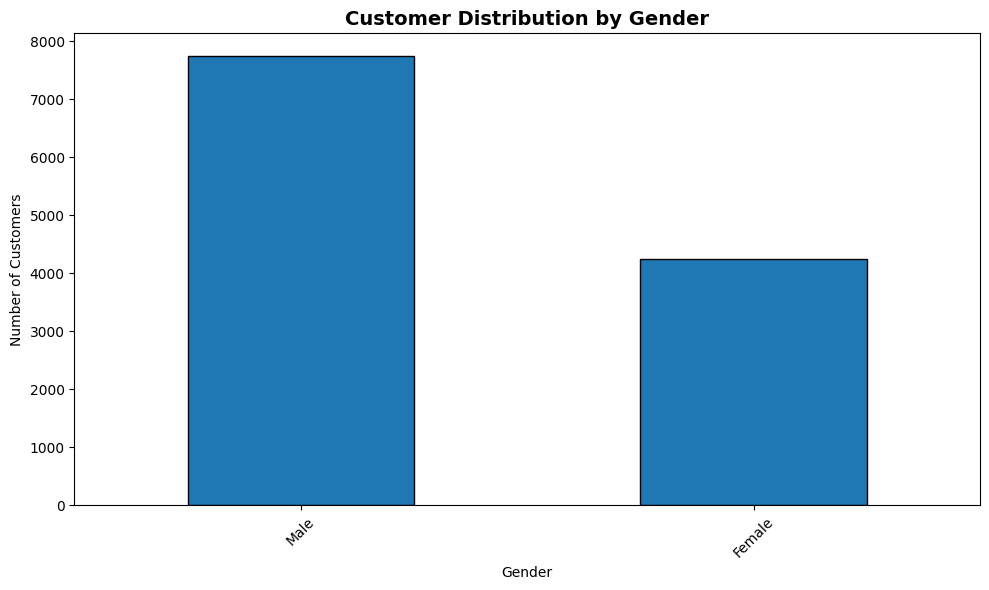

Chart saved successfully: gender_distribution.png


In [73]:
create_bar_chart(
    data=gender_counts,
    title="Customer Distribution by Gender",
    xlabel="Gender",
    ylabel="Number of Customers",
    filename="gender_distribution.png"
)

### Business Insight

- This analysis shows the gender composition of IPL ticket buyers.
- Understanding gender distribution helps marketing teams design targeted promotional campaigns.
- Balanced participation indicates wider audience engagement.

## Business Question

What is the age distribution of IPL customers?

In [74]:
display(customers["Age"].describe())

count    12000.000000
mean        33.291000
std         10.889385
min         18.000000
25%         24.000000
50%         32.000000
75%         40.000000
max         60.000000
Name: Age, dtype: float64

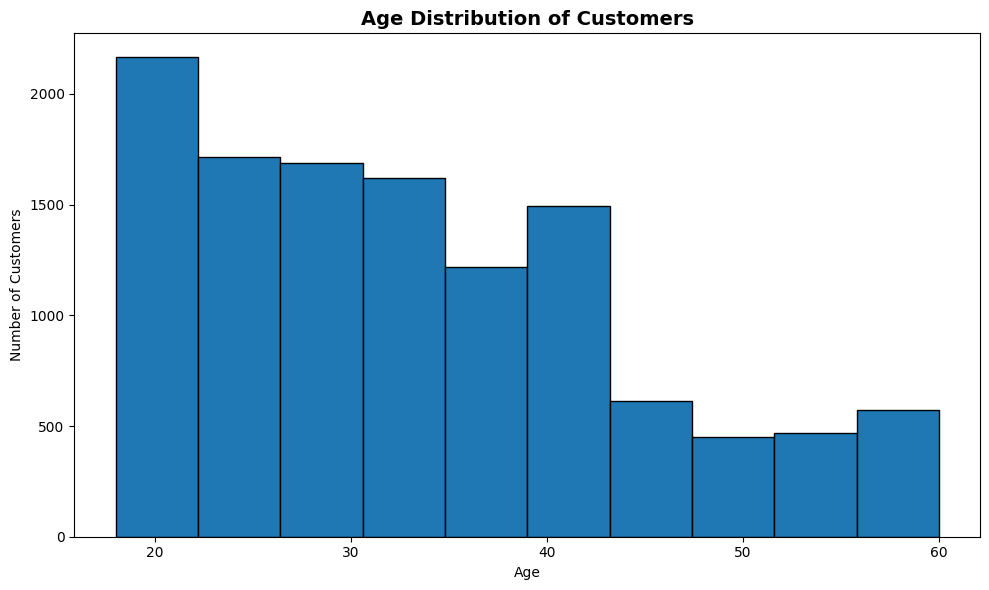

Chart saved successfully: age_distribution.png


In [75]:
plt.figure(figsize=(10,6))

plt.hist(
    customers["Age"],
    bins=10,
    edgecolor="black"
)

plt.title("Age Distribution of Customers", fontsize=14, fontweight="bold")

plt.xlabel("Age")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    CHARTS_FOLDER / "age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully: age_distribution.png")

## Business Question

Which cities have the highest number of registered IPL customers?

In [76]:
city_counts = customers["City"].value_counts()

display(city_counts)

City
Mumbai       1231
Delhi        1228
Ahmedabad    1221
Mohali       1219
Hyderabad    1212
Bengaluru    1204
Chennai      1188
Lucknow      1175
Jaipur       1168
Kolkata      1154
Name: count, dtype: int64

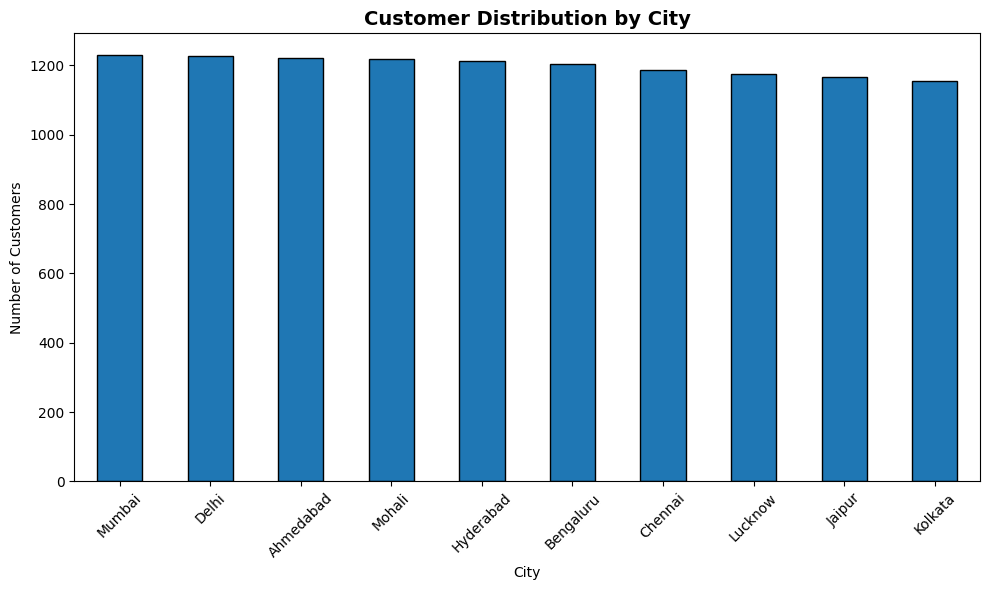

Chart saved successfully: customer_city_distribution.png


In [77]:
create_bar_chart(
    data=city_counts,
    title="Customer Distribution by City",
    xlabel="City",
    ylabel="Number of Customers",
    filename="customer_city_distribution.png"
)

### Business Insight

- Cities with more registered customers represent stronger IPL fan bases.
- These locations are ideal for targeted marketing campaigns and promotional events.

## Business Question

Which states contribute the highest number of IPL customers?

In [78]:
state_counts = customers["State"].value_counts()

display(state_counts)

State
Maharashtra      1231
Delhi            1228
Gujarat          1221
Punjab           1219
Telangana        1212
Karnataka        1204
Tamil Nadu       1188
Uttar Pradesh    1175
Rajasthan        1168
West Bengal      1154
Name: count, dtype: int64

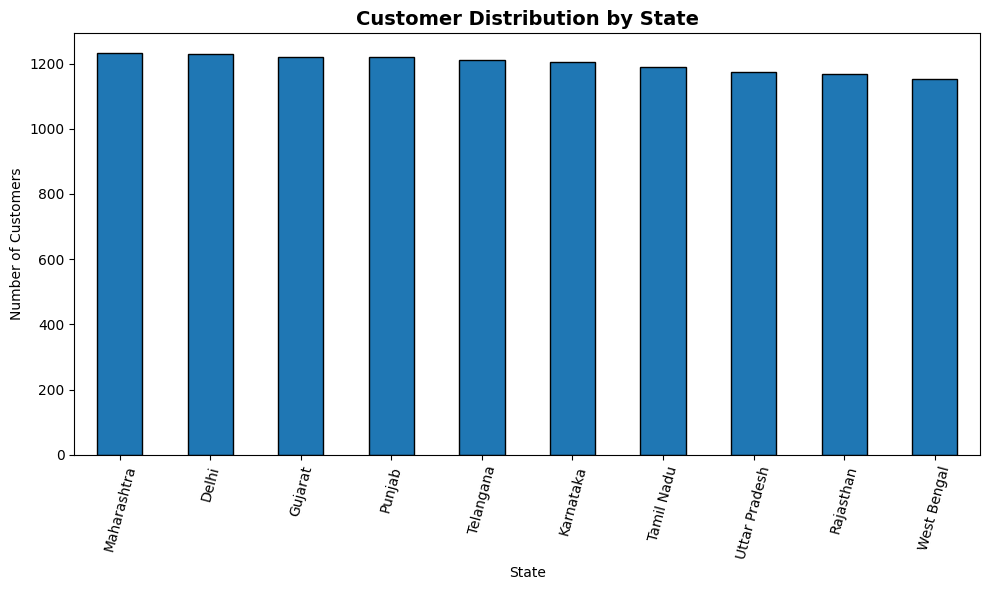

Chart saved successfully: state_distribution.png


In [79]:
create_bar_chart(
    data=state_counts,
    title="Customer Distribution by State",
    xlabel="State",
    ylabel="Number of Customers",
    filename="state_distribution.png",
    rotation=75
)

### Business Insight

- States with a larger customer base contribute significantly to ticket demand.
- This information can support regional marketing and expansion strategies.

## Business Question

Which IPL teams are the most popular among customers?

In [80]:
favorite_team_counts = customers["Favorite_Team"].value_counts()

display(favorite_team_counts)

Favorite_Team
RCB     1715
MI      1673
CSK     1671
KKR     1434
SRH     1191
RR       980
DC       943
LSG      885
GT       806
PBKS     702
Name: count, dtype: int64

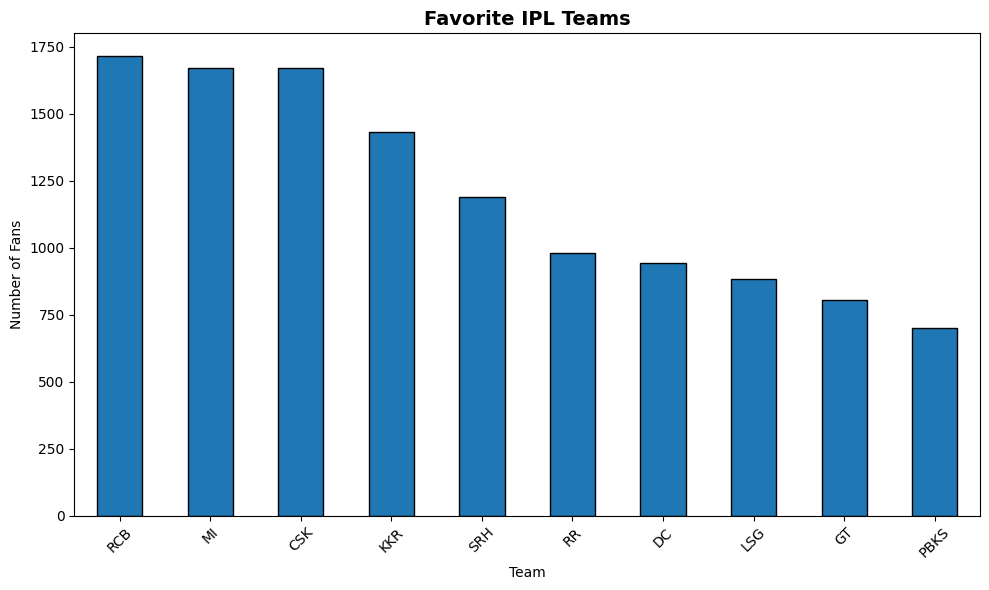

Chart saved successfully: favorite_team_distribution.png


In [81]:
create_bar_chart(
    data=favorite_team_counts,
    title="Favorite IPL Teams",
    xlabel="Team",
    ylabel="Number of Fans",
    filename="favorite_team_distribution.png"
)

### Business Insight

- Popular teams attract a larger fan base and have higher merchandising and ticket sales potential.
- Understanding fan preferences helps improve promotional campaigns and sponsorship planning.

## Business Question

Which occupations contribute the highest number of IPL ticket customers?

In [82]:
occupation_counts = customers["Occupation"].value_counts()

display(occupation_counts)

Occupation
Chartered Accountant    630
Freelancer              627
Student                 618
Software Engineer       610
Marketing Executive     608
Business Owner          607
Government Employee     607
Data Scientist          604
Entrepreneur            601
Police Officer          600
Sales Executive         600
Graphic Designer        598
Doctor                  593
Data Analyst            592
Mechanical Engineer     592
Nurse                   590
Teacher                 585
Civil Engineer          583
Lawyer                  579
Banker                  576
Name: count, dtype: int64

In [83]:
top_10_occupations = occupation_counts.head(10)

display(top_10_occupations)

Occupation
Chartered Accountant    630
Freelancer              627
Student                 618
Software Engineer       610
Marketing Executive     608
Business Owner          607
Government Employee     607
Data Scientist          604
Entrepreneur            601
Police Officer          600
Name: count, dtype: int64

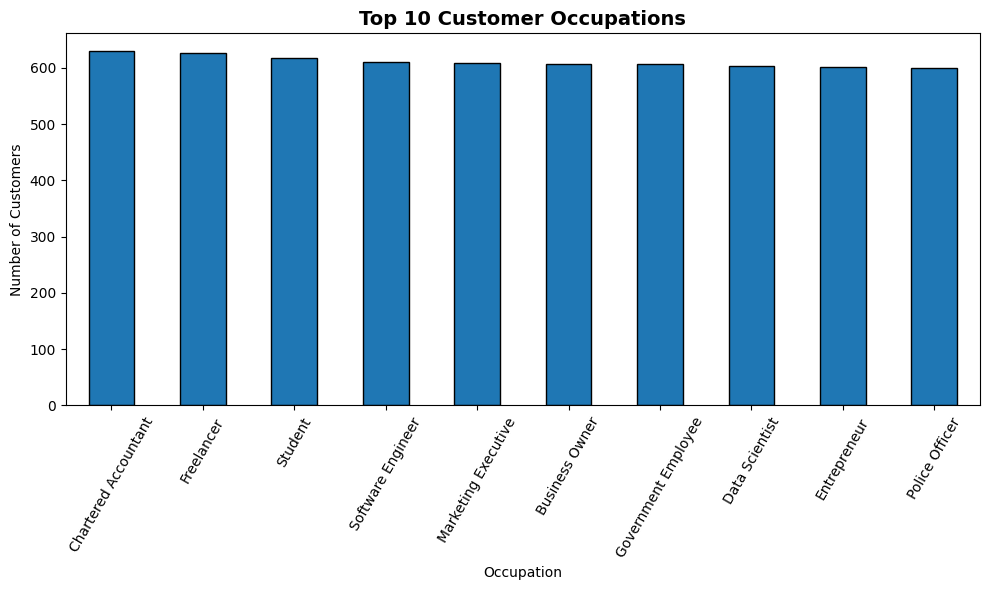

Chart saved successfully: occupation_distribution.png


In [84]:
create_bar_chart(
    data=top_10_occupations,
    title="Top 10 Customer Occupations",
    xlabel="Occupation",
    ylabel="Number of Customers",
    filename="occupation_distribution.png",
    rotation=60
)

### Business Insight

- The top occupations represent the largest customer segments purchasing IPL tickets.
- These customer groups can be targeted with occupation-specific offers and promotional campaigns.
- Understanding occupation trends helps identify customer demographics and spending behavior.

## Business Question

How are customers distributed across different loyalty tiers?

In [85]:
loyalty_counts = customers["Loyalty_Tier"].value_counts()

display(loyalty_counts)

Loyalty_Tier
Bronze      6086
Silver      3529
Gold        1795
Platinum     590
Name: count, dtype: int64

In [86]:
loyalty_percentage = (
    customers["Loyalty_Tier"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(loyalty_percentage)

Loyalty_Tier
Bronze      50.72
Silver      29.41
Gold        14.96
Platinum     4.92
Name: proportion, dtype: float64

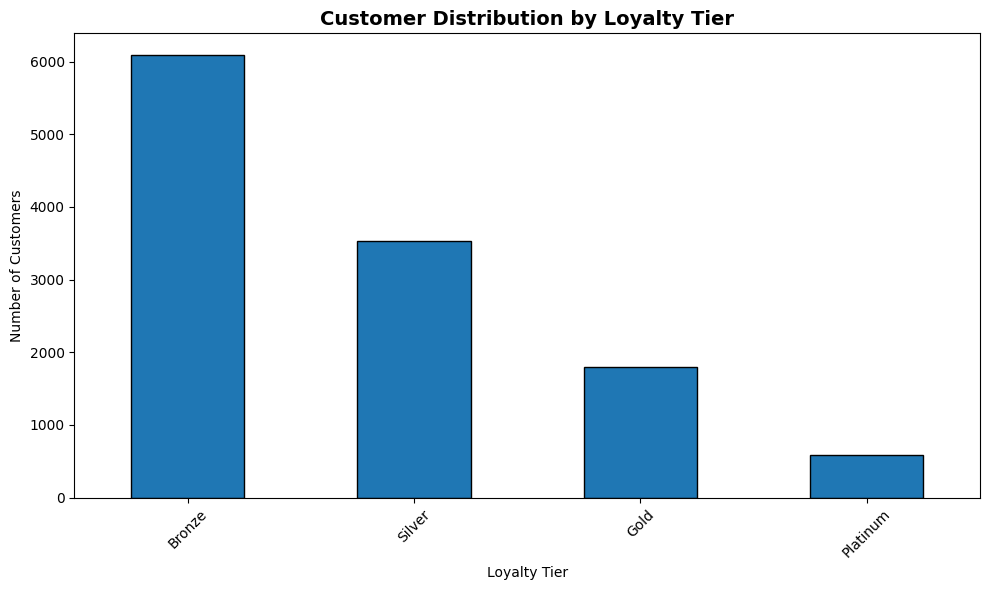

Chart saved successfully: loyalty_distribution.png


In [87]:
create_bar_chart(
    data=loyalty_counts,
    title="Customer Distribution by Loyalty Tier",
    xlabel="Loyalty Tier",
    ylabel="Number of Customers",
    filename="loyalty_distribution.png"
)

### Business Insight

- The loyalty tier distribution shows customer retention levels.
- A larger Bronze customer base indicates opportunities to encourage customers to upgrade to higher loyalty tiers through rewards and personalized offers.

## Business Question

What is the income distribution of IPL customers?

In [88]:
display(customers["Annual_Income"].describe())

count    1.200000e+04
mean     1.133405e+06
std      8.657516e+05
min      4.400000e+02
25%      5.980930e+05
50%      8.712695e+05
75%      1.390806e+06
max      4.998895e+06
Name: Annual_Income, dtype: float64

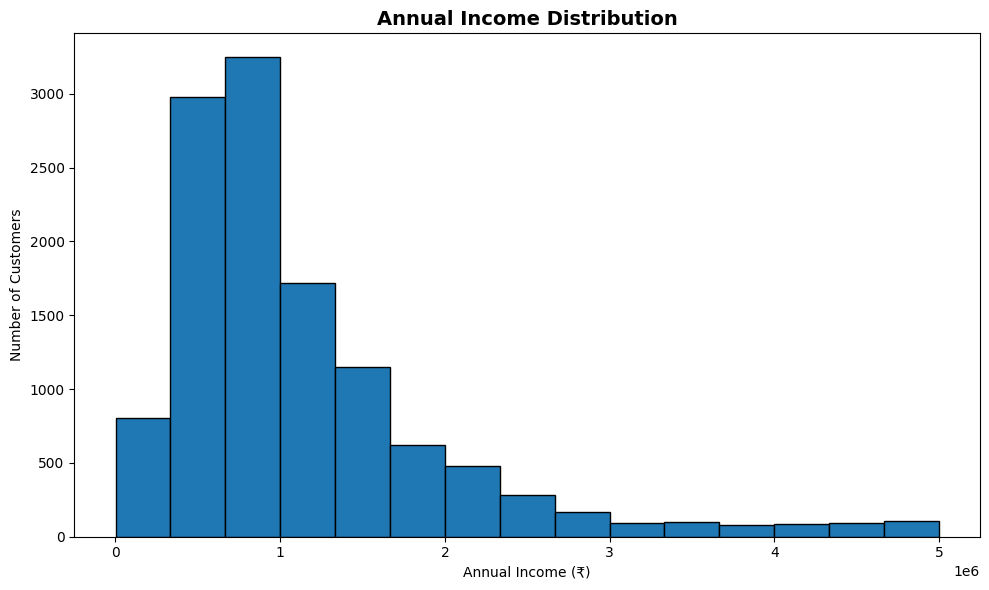

Chart saved successfully: annual_income_distribution.png


In [89]:
plt.figure(figsize=(10,6))

plt.hist(
    customers["Annual_Income"],
    bins=15,
    edgecolor="black"
)

plt.title("Annual Income Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Annual Income (₹)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    CHARTS_FOLDER / "annual_income_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully: annual_income_distribution.png")

### Business Insight

- Customer income levels help identify purchasing power.
- Higher-income customers are more likely to purchase premium seating and VIP experiences.
- Income segmentation supports targeted pricing and marketing strategies.

## Business Question

How have customer registrations changed over time?

In [91]:
registration_month = (
    customers["Registration_Date"]
    .dt.to_period("M")
    .astype(str)
    .value_counts()
    .sort_index()
)

display(registration_month)

Registration_Date
2024-01    443
2024-02    409
2024-03    455
2024-04    443
2024-05    472
2024-06    456
2024-07    461
2024-08    443
2024-09    462
2024-10    449
2024-11    429
2024-12    440
2025-01    466
2025-02    421
2025-03    481
2025-04    444
2025-05    465
2025-06    432
2025-07    454
2025-08    445
2025-09    446
2025-10    476
2025-11    446
2025-12    427
2026-01    447
2026-02    381
2026-03    407
Name: count, dtype: int64

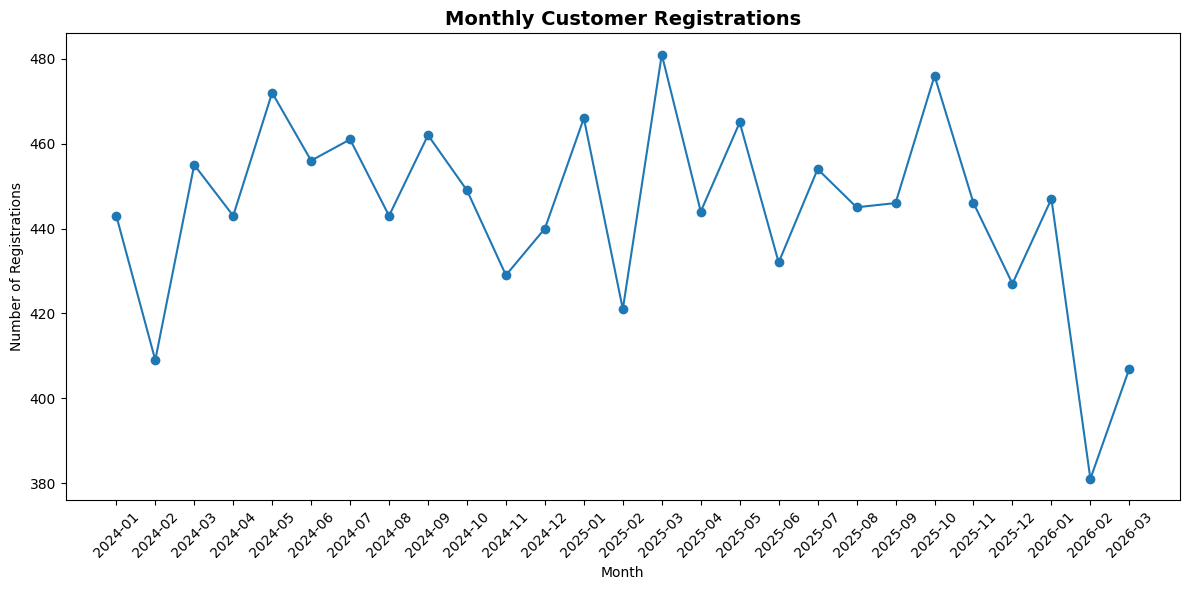

Chart saved successfully: customer_registration_trend.png


In [92]:
plt.figure(figsize=(12,6))

plt.plot(
    registration_month.index,
    registration_month.values,
    marker="o"
)

plt.title("Monthly Customer Registrations", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Registrations")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    CHARTS_FOLDER / "customer_registration_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully: customer_registration_trend.png")

### Business Insight

- Registration trends reveal periods of increased customer acquisition.
- Peaks may correspond to IPL season announcements, promotional campaigns, or ticket sale launches.
- Understanding these trends helps optimize future marketing efforts.

# Ticket Sales Dataset - Univariate Analysis

## Business Question

Which seat category is purchased the most by customers?

In [93]:
seat_counts = ticket_sales["Seat_Category"].value_counts()

display(seat_counts)

Seat_Category
Economy    89839
Premium    45015
VIP        15146
Name: count, dtype: int64

In [94]:
seat_percentage = (
    ticket_sales["Seat_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(seat_percentage)

Seat_Category
Economy    59.89
Premium    30.01
VIP        10.10
Name: proportion, dtype: float64

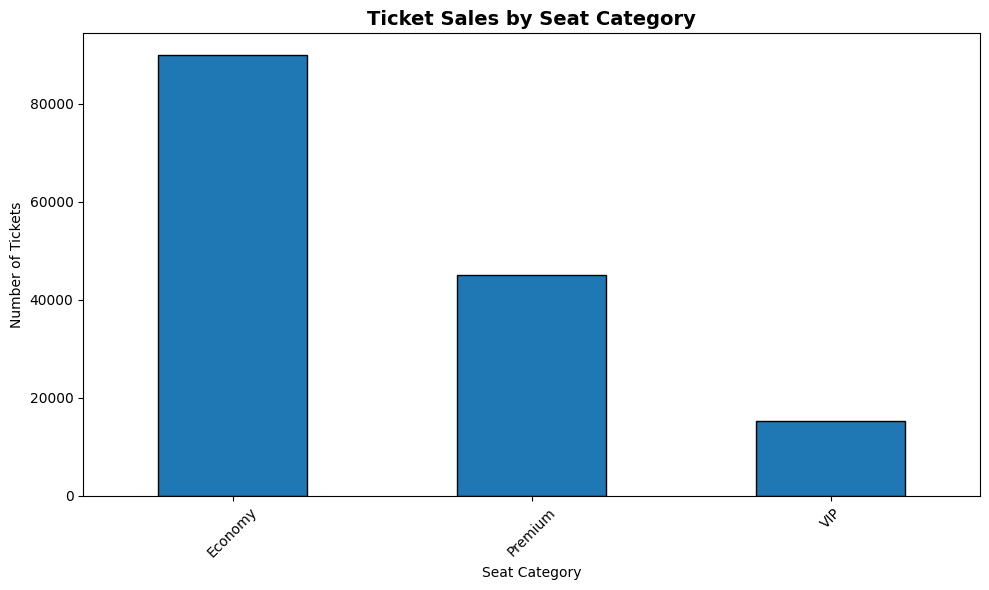

Chart saved successfully: seat_category_distribution.png


In [95]:
create_bar_chart(
    data=seat_counts,
    title="Ticket Sales by Seat Category",
    xlabel="Seat Category",
    ylabel="Number of Tickets",
    filename="seat_category_distribution.png"
)

### Business Insight

- Economy seating generally contributes the highest ticket volume.
- Premium and VIP categories contribute higher revenue per ticket.
- This information supports pricing and inventory decisions.

## Business Question

What is the distribution of booking statuses?

In [97]:
booking_status_counts = ticket_sales["Booking_Status"].value_counts()

display(booking_status_counts)

Booking_Status
Confirmed    142504
Cancelled      7496
Name: count, dtype: int64

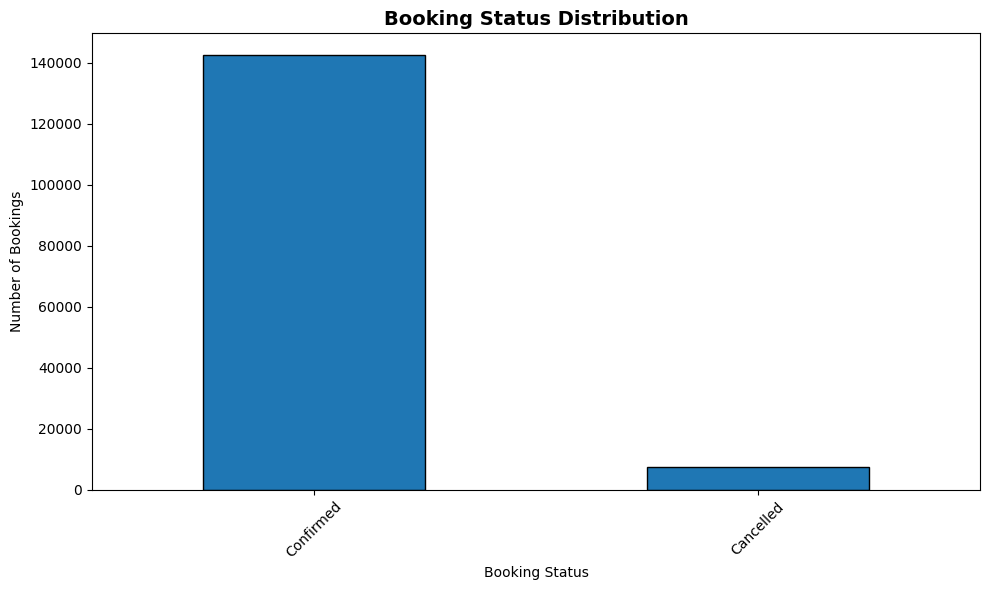

Chart saved successfully: booking_status_distribution.png


In [98]:
create_bar_chart(
    data=booking_status_counts,
    title="Booking Status Distribution",
    xlabel="Booking Status",
    ylabel="Number of Bookings",
    filename="booking_status_distribution.png"
)

### Business Insight

- Most bookings are expected to be confirmed.
- Cancelled bookings indicate revenue leakage and can be analyzed further.

## Business Question

Which payment method is preferred by customers?

In [99]:
payment_counts = ticket_sales["Payment_Method"].value_counts()

display(payment_counts)

Payment_Method
UPI            67378
Credit Card    37783
Debit Card     30028
Net Banking    14811
Name: count, dtype: int64

In [100]:
payment_percentage = (
    ticket_sales["Payment_Method"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(payment_percentage)

Payment_Method
UPI            44.92
Credit Card    25.19
Debit Card     20.02
Net Banking     9.87
Name: proportion, dtype: float64

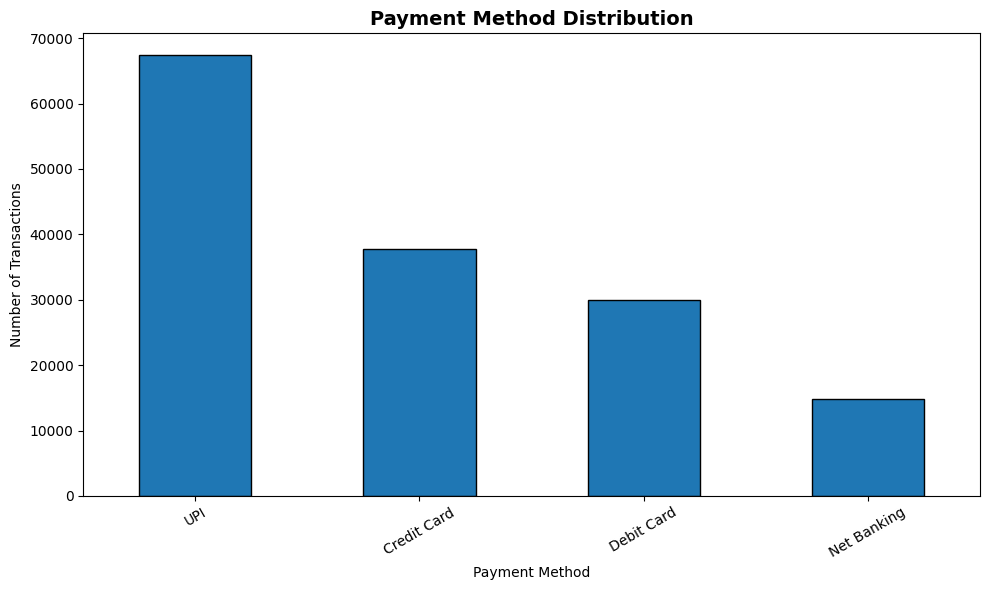

Chart saved successfully: payment_method_distribution.png


In [101]:
create_bar_chart(
    data=payment_counts,
    title="Payment Method Distribution",
    xlabel="Payment Method",
    ylabel="Number of Transactions",
    filename="payment_method_distribution.png",
    rotation=30
)

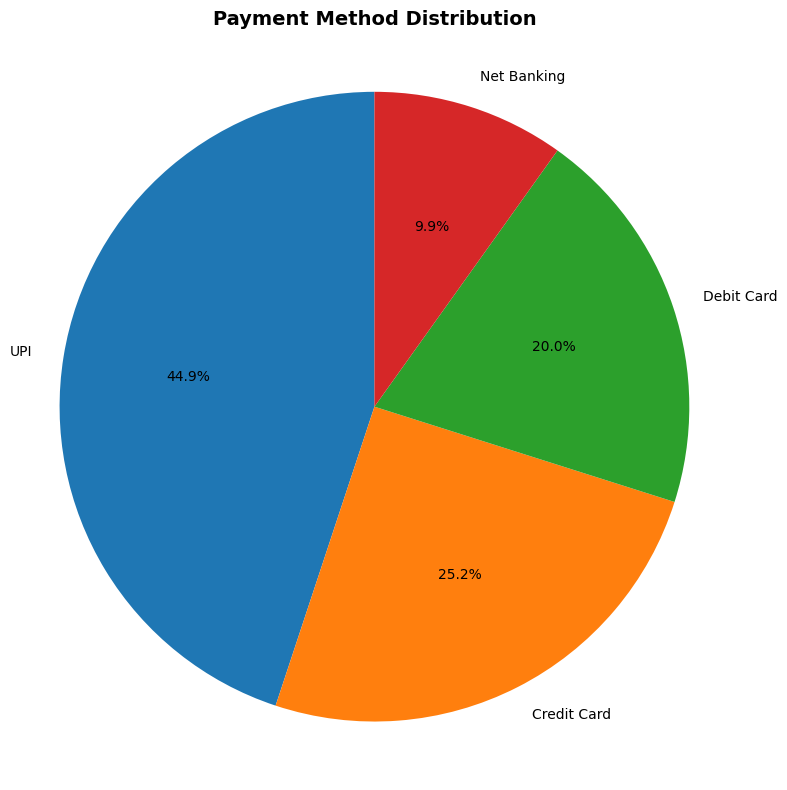

Chart saved successfully: payment_method_distribution_pie.png


In [106]:
create_pie_chart(
    data=payment_counts,
    title="Payment Method Distribution",
    filename="payment_method_distribution_pie.png"
)

### Business Insight

- Understanding preferred payment methods helps optimize payment gateway performance.
- Popular payment methods should receive priority during promotional campaigns.

## Business Question

How many tickets are purchased in each booking?

In [107]:
display(ticket_sales["Quantity"].describe())

count    150000.000000
mean          1.698887
std           0.842240
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           4.000000
Name: Quantity, dtype: float64

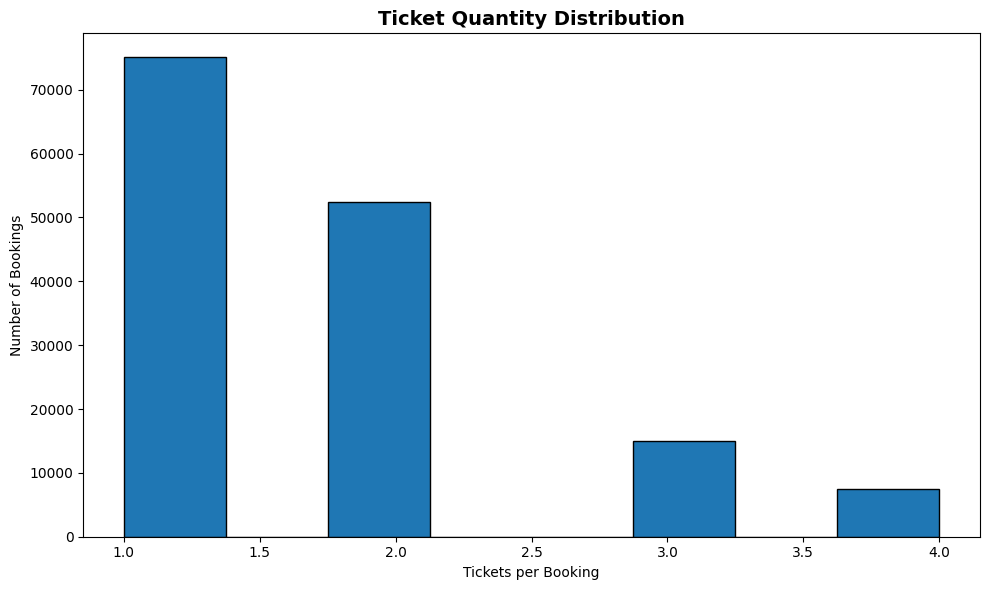

Chart saved successfully: ticket_quantity_distribution.png


In [108]:
plt.figure(figsize=(10,6))

plt.hist(
    ticket_sales["Quantity"],
    bins=8,
    edgecolor="black"
)

plt.title("Ticket Quantity Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Tickets per Booking")
plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(
    CHARTS_FOLDER / "ticket_quantity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully: ticket_quantity_distribution.png")

### Business Insight

- Most bookings contain a small number of tickets.
- Larger bookings may indicate group purchases and should be targeted with group discounts.

## Business Question

How are ticket prices distributed?

In [109]:
display(ticket_sales["Ticket_Price"].describe())

count    150000.000000
mean       1584.208000
std        1264.255539
min         800.000000
25%         800.000000
50%         800.000000
75%        2000.000000
max        5000.000000
Name: Ticket_Price, dtype: float64

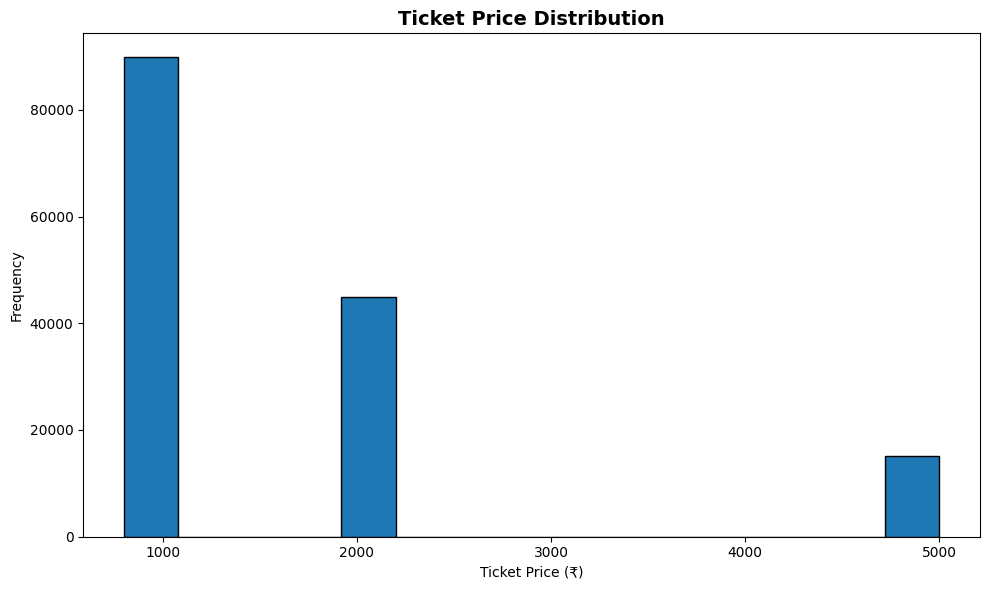

Chart saved successfully: ticket_price_distribution.png


In [110]:
plt.figure(figsize=(10,6))

plt.hist(
    ticket_sales["Ticket_Price"],
    bins=15,
    edgecolor="black"
)

plt.title("Ticket Price Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Ticket Price (₹)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    CHARTS_FOLDER / "ticket_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully: ticket_price_distribution.png")

### Business Insight

- Ticket pricing reflects different seating categories.
- Price analysis helps identify customer affordability and pricing strategies.

## Business Question

What is the distribution of total booking values?

In [111]:
display(ticket_sales["Total_Amount"].describe())

count    150000.000000
mean       2693.573333
std        2748.916491
min         800.000000
25%         800.000000
50%        1600.000000
75%        4000.000000
max       20000.000000
Name: Total_Amount, dtype: float64

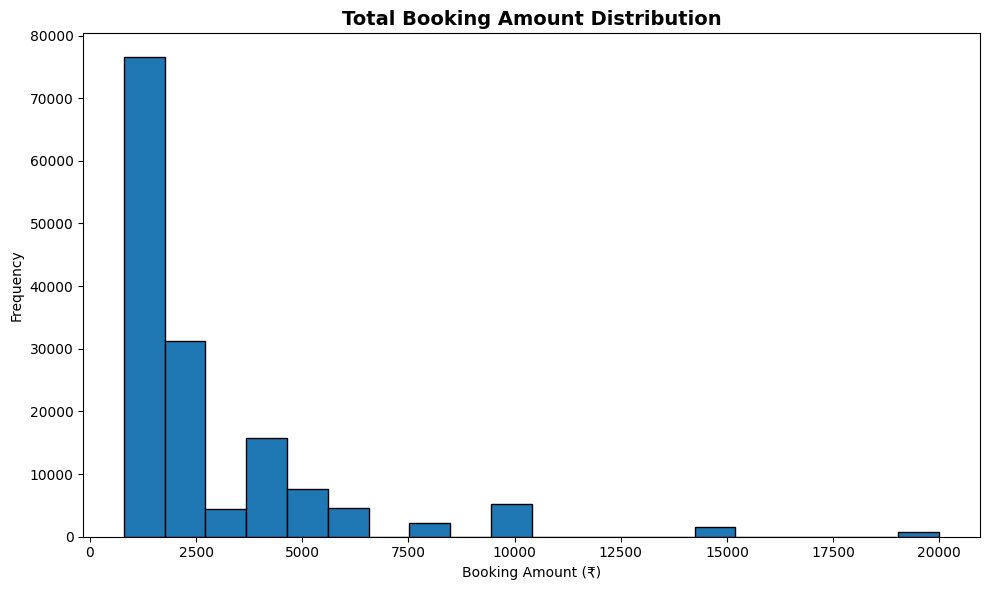

Chart saved successfully: total_amount_distribution.png


In [112]:
plt.figure(figsize=(10,6))

plt.hist(
    ticket_sales["Total_Amount"],
    bins=20,
    edgecolor="black"
)

plt.title("Total Booking Amount Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Booking Amount (₹)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    CHARTS_FOLDER / "total_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully: total_amount_distribution.png")

### Business Insight

- Booking value distribution highlights customer spending patterns.
- High-value bookings represent premium customers and potential VIP segments.

## Business Question

How have ticket bookings changed over time?

In [113]:
booking_trend = (
    ticket_sales["Booking_Date"]
    .dt.to_period("M")
    .astype(str)
    .value_counts()
    .sort_index()
)

display(booking_trend)

Booking_Date
2026-01      505
2026-02    18395
2026-03    50908
2026-04    53422
2026-05    25330
2026-06     1440
Name: count, dtype: int64

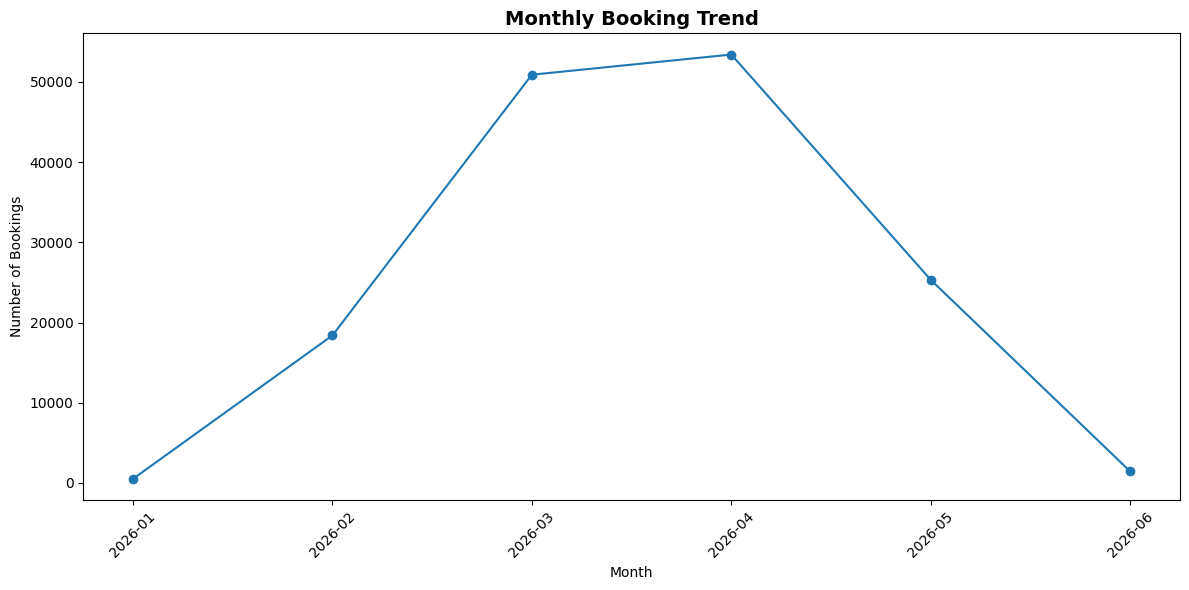

Chart saved successfully: booking_trend.png


In [114]:
plt.figure(figsize=(12,6))

plt.plot(
    booking_trend.index,
    booking_trend.values,
    marker="o"
)

plt.title("Monthly Booking Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    CHARTS_FOLDER / "booking_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully: booking_trend.png")

### Business Insight

- Booking trends identify peak demand periods.
- These insights help optimize marketing campaigns and ticket release schedules.